## Disparity analysis

This notebook covers three angles on inequity. The first is the dose response of health outcomes across SVI quintiles. The second is the Black versus White infant mortality rate ratio reported with a 95 percent confidence interval. The third is HRRP regressivity, which tests whether Medicare's readmission penalty falls harder on hospitals serving more vulnerable counties.

### Importing necessary libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine, text
import os
from dotenv import load_dotenv

load_dotenv('../.env')
host = os.getenv('PGHOST', 'localhost')
port = os.getenv('PGPORT', '5432')
db = os.getenv('PGDATABASE', 'ms_health')
user = os.getenv('PGUSER', 'postgres')
pwd = os.getenv('PGPASSWORD', '')
engine = create_engine(f'postgresql+psycopg://{user}:{pwd}@{host}:{port}/{db}')
sns.set(style='whitegrid')

def q(sql):
    return pd.read_sql(text(sql), engine)

### Dose response: do health outcomes worsen monotonically with SVI?

In [2]:
# Population-weighted prevalence of six PLACES outcomes per SVI quintile, latest year.
df = q("""
WITH svi_buckets AS (
    SELECT g.geo_sk, g.tract_fips, g.total_population,
        NTILE(5) OVER (ORDER BY s.rpl_themes) AS svi_quintile
    FROM dim_geography g
    JOIN fact_svi_wide s ON s.geo_sk = g.geo_sk
    WHERE s.rpl_themes IS NOT NULL
),
places_pivot AS (
    SELECT b.svi_quintile, b.tract_fips, b.total_population,
        AVG(f.data_value) FILTER (WHERE m.measure_id = 'DIABETES') AS diabetes_pct,
        AVG(f.data_value) FILTER (WHERE m.measure_id = 'BPHIGH') AS bphigh_pct,
        AVG(f.data_value) FILTER (WHERE m.measure_id = 'OBESITY') AS obesity_pct,
        AVG(f.data_value) FILTER (WHERE m.measure_id = 'CSMOKING') AS smoking_pct,
        AVG(f.data_value) FILTER (WHERE m.measure_id = 'DEPRESSION') AS depression_pct,
        AVG(f.data_value) FILTER (WHERE m.measure_id = 'ACCESS2') AS uninsured_pct
    FROM svi_buckets b
    JOIN fact_places f ON f.geo_sk = b.geo_sk
    JOIN dim_measure m ON m.measure_sk = f.measure_sk
    WHERE m.source = 'PLACES'
    AND f.year_sk = (SELECT MAX(year_sk) FROM fact_places)
    GROUP BY b.svi_quintile, b.tract_fips, b.total_population
)
SELECT svi_quintile,
    COUNT(*) AS tracts,
    SUM(total_population) AS pop,
    ROUND(SUM(diabetes_pct * total_population) / NULLIF(SUM(total_population), 0)::NUMERIC, 2) AS diabetes,
    ROUND(SUM(bphigh_pct * total_population) / NULLIF(SUM(total_population), 0)::NUMERIC, 2) AS bp_high,
    ROUND(SUM(obesity_pct * total_population) / NULLIF(SUM(total_population), 0)::NUMERIC, 2) AS obesity,
    ROUND(SUM(smoking_pct * total_population) / NULLIF(SUM(total_population), 0)::NUMERIC, 2) AS smoking,
    ROUND(SUM(depression_pct * total_population) / NULLIF(SUM(total_population), 0)::NUMERIC, 2) AS depression,
    ROUND(SUM(uninsured_pct * total_population) / NULLIF(SUM(total_population), 0)::NUMERIC, 2) AS uninsured
FROM places_pivot
GROUP BY svi_quintile
ORDER BY svi_quintile
""")
df

,svi_quintile,tracts,pop,diabetes,bp_high,obesity,smoking,depression,uninsured
0,1,174,626928,11.77,39.33,34.89,12.94,19.73,8.17
1,2,174,599038,13.79,42.38,37.89,15.61,20.03,9.98
2,3,174,601147,15.26,44.59,40.07,17.31,20.02,11.39
3,4,174,581327,17.76,47.95,43.54,19.50,19.60,13.22
4,5,174,550301,21.04,51.98,47.52,22.83,19.22,15.96


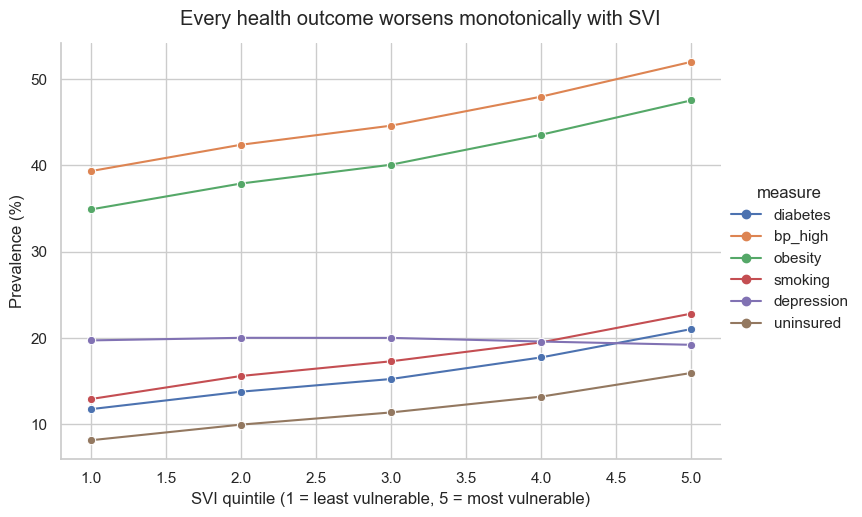

In [3]:
# Line plot of all six outcomes across SVI quintiles.
long = df.melt(id_vars=['svi_quintile','tracts','pop'], var_name='measure', value_name='pct')
g = sns.relplot(data=long, x='svi_quintile', y='pct', hue='measure', kind='line',
                marker='o', height=5, aspect=1.5)
g.set_axis_labels('SVI quintile (1 = least vulnerable, 5 = most vulnerable)', 'Prevalence (%)')
g.fig.suptitle('Every health outcome worsens monotonically with SVI', y=1.03)
plt.show()

### Black versus White infant mortality rate ratio with 95% CI

In [4]:
# Black:White IMR rate ratio with 95 percent CI computed in SQL via the Katz
# log rate ratio formula: SE(log RR) = sqrt(1/d_a - 1/n_a + 1/d_b - 1/n_b),
# then bounds = exp(log(RR) +/- 1.96 * SE).
q("""
WITH black_white AS (
    SELECT
        MAX(infant_deaths) FILTER (WHERE county_name ILIKE '%Black race%') AS d_black,
        MAX(live_births) FILTER (WHERE county_name ILIKE '%Black race%') AS n_black,
        MAX(imr_per_1000) FILTER (WHERE county_name ILIKE '%Black race%') AS imr_black,
        MAX(infant_deaths) FILTER (WHERE county_name ILIKE '%White race%') AS d_white,
        MAX(live_births) FILTER (WHERE county_name ILIKE '%White race%') AS n_white,
        MAX(imr_per_1000) FILTER (WHERE county_name ILIKE '%White race%') AS imr_white
    FROM stg_msdh_imr_race
)
SELECT imr_black, imr_white,
    ROUND((imr_black / imr_white)::NUMERIC, 3) AS rate_ratio,
    ROUND(EXP(LN(imr_black / imr_white) - 1.96 * SQRT(1.0/d_black - 1.0/n_black + 1.0/d_white - 1.0/n_white))::NUMERIC, 3) AS ci_lower_95,
    ROUND(EXP(LN(imr_black / imr_white) + 1.96 * SQRT(1.0/d_black - 1.0/n_black + 1.0/d_white - 1.0/n_white))::NUMERIC, 3) AS ci_upper_95
FROM black_white
""")

,imr_black,imr_white,rate_ratio,ci_lower_95,ci_upper_95
0,15.2,5.8,2.621,2.062,3.332


Infant mortality in Mississippi's Black population is 2.6 times the rate in the White population (Black IMR 15.2 versus White IMR 5.8). The 95 percent confidence interval is [2.06, 3.33], and because the lower bound sits well above 1.0 this disparity is not sampling noise.

### HRRP regressivity: does Medicare penalize hospitals serving the poor more?

In [5]:
# Average HRRP Excess Readmission Ratio per SVI quintile of the host county.
# A flat gradient would indicate the penalty is risk-neutral; a rising gradient
# indicates regressivity against hospitals serving vulnerable counties.
q("""
WITH hospital_quintile AS (
    SELECT f.facility_sk,
        NTILE(5) OVER (ORDER BY s.rpl_themes) AS svi_quintile
    FROM dim_facility f
    JOIN svi_county s ON s.county_fips = f.county_fips
    WHERE f.state_abbr = 'MS'
)
SELECT h.svi_quintile,
    COUNT(DISTINCT h.facility_sk) AS hospitals,
    ROUND(AVG(q.score) FILTER (WHERE q.measure_id = 'READM-30-AMI-HRRP')::NUMERIC, 3) AS ami_err,
    ROUND(AVG(q.score) FILTER (WHERE q.measure_id = 'READM-30-HF-HRRP')::NUMERIC, 3) AS hf_err,
    ROUND(AVG(q.score) FILTER (WHERE q.measure_id = 'READM-30-COPD-HRRP')::NUMERIC, 3) AS copd_err,
    ROUND(AVG(q.score)::NUMERIC, 3) AS overall_avg_err,
    ROUND(100.0 * SUM(CASE WHEN q.score > 1.0 THEN 1 ELSE 0 END) / COUNT(*), 1) AS pct_worse_than_expected
FROM hospital_quintile h
JOIN fact_hospital_quality q ON q.facility_sk = h.facility_sk
WHERE q.measure_type = 'HRRP'
GROUP BY h.svi_quintile
ORDER BY h.svi_quintile
""")

,svi_quintile,hospitals,ami_err,hf_err,copd_err,overall_avg_err,pct_worse_than_expected
0,1,11,1.039,1.039,1.008,1.025,67.5
1,2,12,1.020,1.030,1.004,1.003,55.8
2,3,8,1.020,1.032,1.015,1.031,64.5
3,4,9,0.997,1.008,1.001,0.998,60.0
4,5,8,1.038,1.000,1.049,1.023,63.6
